# Chapter 17: Stacking and Hill-Climbing

**As the candidate library fills with near-duplicate models, how much of the hill-climbing improvement shows up on assessment rows?**

The chapter warns that greedy search can overfit repeated development comparisons, and that an old score does not show the benefit. Measuring development against assessment gain shows what extra candidates are worth.

*Constructed data with deliberate near-duplicates. The assessment loss did not rise with library size, so the extra candidates were harmless here but also nearly useless; the sizes are properties of this generator.*

## The experiment

A constructed binary task with 20 features, six of them informative. Four logistic-regression families each read five features and are fitted on 400 rows; the library then grows by bootstrap refits of those same four, so the extras are near-duplicates. The chapter's greedy_brier_weights runs on 200 development rows and is scored by Brier loss on those rows and on 5,000 assessment rows, against the same search on the four original models. Twenty-five independent datasets are averaged.

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression

from kaggle_companion.activities._common import clean

SEED = 17
REPLICATES = 25                    # independent constructed datasets; every estimate is their mean
FEATURES, FAMILIES = 20, 4         # 20 features, 6 of them informative; 4 genuinely different model families
N_TRAIN, N_DEV, N_ASSESS = 400, 200, 5000


def generate(rng, n, coef):
    X = rng.normal(size=(n, FEATURES))
    y = (rng.random(n) < 1 / (1 + np.exp(-(X @ coef)))).astype(int)
    return X, y


def greedy_brier_weights(y_development, candidate_predictions, step=0.1, max_iterations=30):
    """The chapter's hill-climbing function: start from the best candidate, then repeatedly move `step` of the weight
    to whichever candidate lowers the development Brier loss most, and stop when nothing helps."""
    y = np.asarray(y_development, dtype=float)
    p = np.asarray(candidate_predictions, dtype=float)
    if p.ndim != 2 or p.shape[0] != len(y) or p.shape[1] == 0:
        raise ValueError('rows by candidate matrix required')
    if not np.isfinite(p).all() or ((p < 0) | (p > 1)).any():
        raise ValueError('finite binary probabilities required')
    if not np.isin(y, [0, 1]).all() or not 0 < step <= 1:
        raise ValueError('binary labels and step in (0,1] required')
    loss = lambda q: np.mean((q - y) ** 2)
    start = int(np.argmin(np.mean((p - y[:, None]) ** 2, axis=0)))
    weights = np.eye(p.shape[1])[start]
    current = p @ weights
    for _ in range(max_iterations):
        choices = (1 - step) * current[:, None] + step * p
        losses = np.mean((choices - y[:, None]) ** 2, axis=0)
        winner = int(np.argmin(losses))
        if losses[winner] >= loss(current) - 1e-12:
            break
        weights *= 1 - step
        weights[winner] += step
        current = p @ weights
    return weights


def brier(y, p):
    return float(np.mean((p - y) ** 2))


def run(library_size):
    rows = []
    for rep in range(REPLICATES):
        rng = np.random.default_rng(SEED * 100 + rep)
        coef = np.zeros(FEATURES)
        coef[:6] = rng.normal(0, 0.8, 6)
        (X, y), (Xd, yd), (Xa, ya) = [generate(rng, n, coef) for n in (N_TRAIN, N_DEV, N_ASSESS)]
        columns = [rng.choice(FEATURES, 5, replace=False) for _ in range(FAMILIES)]   # each family reads five features
        Pd, Pa = np.zeros((N_DEV, library_size)), np.zeros((N_ASSESS, library_size))
        for j in range(library_size):
            cols = columns[j % FAMILIES]
            rows_used = np.arange(N_TRAIN) if j < FAMILIES else rng.integers(0, N_TRAIN, N_TRAIN)  # extras: bootstrap refits
            model = LogisticRegression(max_iter=300).fit(X[rows_used][:, cols], y[rows_used])
            Pd[:, j], Pa[:, j] = model.predict_proba(Xd[:, cols])[:, 1], model.predict_proba(Xa[:, cols])[:, 1]
        best = int(np.argmin([brier(yd, Pd[:, j]) for j in range(library_size)]))   # best single candidate, chosen on development rows
        w_all = greedy_brier_weights(yd, Pd)
        w_start = greedy_brier_weights(yd, Pd[:, :FAMILIES])                        # the same search on the four original models
        rows.append({
            "best": (brier(yd, Pd[:, best]), brier(ya, Pa[:, best])),
            "equal": (brier(yd, Pd.mean(axis=1)), brier(ya, Pa.mean(axis=1))),
            "greedy": (brier(yd, Pd @ w_all), brier(ya, Pa @ w_all)),
            "greedy_start": (brier(yd, Pd[:, :FAMILIES] @ w_start), brier(ya, Pa[:, :FAMILIES] @ w_start)),
            "kept": int((w_all > 0).sum()),
        })
    pick = lambda name, i: np.array([r[name][i] for r in rows])
    gain_dev = pick("greedy_start", 0) - pick("greedy", 0)        # what the extra candidates add on the rows the search used
    gain_assess = pick("greedy_start", 1) - pick("greedy", 1)     # what they add on assessment rows
    return clean({
        "library_size": library_size, "candidates_kept": float(np.mean([r["kept"] for r in rows])),
        "development": {k: float(pick(k, 0).mean()) for k in ("best", "equal", "greedy", "greedy_start")},
        "assessment": {k: float(pick(k, 1).mean()) for k in ("best", "equal", "greedy", "greedy_start")},
        "added_gain_development": float(gain_dev.mean()), "added_gain_assessment": float(gain_assess.mean()),
        "per_replicate": {"development": gain_dev, "assessment": gain_assess},
        "replicates": REPLICATES, "development_rows": N_DEV, "assessment_rows": N_ASSESS,
    })


## Measure it across the control

The control is **candidates in the library**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch17 import explain

VALUES = [4, 12, 40, 100]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                 4      12      40     100
Candidates                       4      12      40     100
Hill-climbing, development   0.203   0.201   0.198   0.196
Hill-climbing, assessment    0.207   0.207   0.206   0.205
Added gain, development     0.0000  0.0022  0.0052  0.0069
Added gain, assessment      0.0000  0.0003  0.0012  0.0019


## Look at it

The figure shows the default setting, candidates in the library = 100.

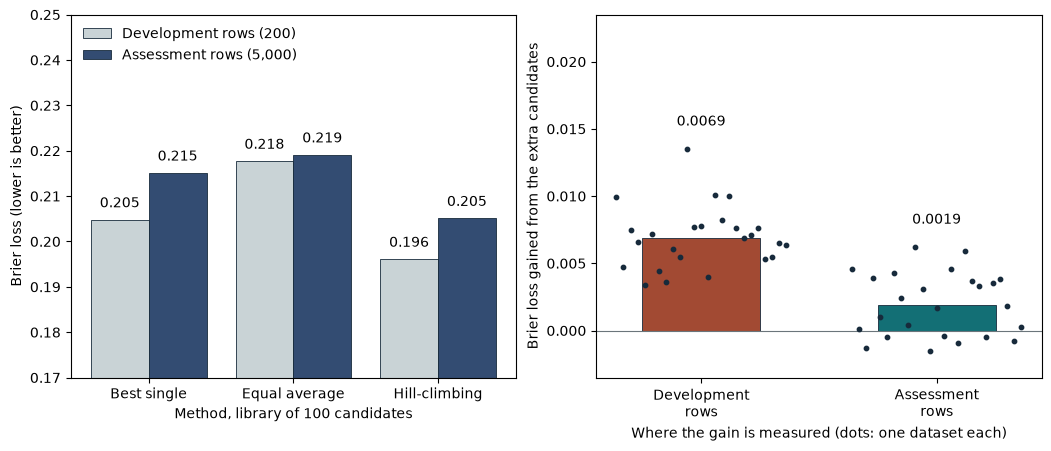

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch17 import draw, NCOLS, HEIGHT

DEFAULT = 100
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 100 candidates the search kept 4.4 on average. Its development Brier loss is 0.196; on assessment rows it is 0.205, so 0.205 - 0.196 = 0.009 of optimism (the equal average, which chooses nothing on the development rows, differs by 0.001). The 96 extra candidates lowered the development loss by 0.0069 and the assessment loss by 0.0019, 28% of it. The best single candidate scores 0.215 on assessment rows and the equal average 0.219.

- Optimism of the search: 0.205 - 0.196 = 0.009 Brier (assessment minus development).
- Development gain from 96 extra candidates: 0.203 - 0.196 = 0.007.
- Assessment gain from the same candidates: 0.207 - 0.205 = 0.002.
- Hill-climbing against the best single candidate on assessment rows: 0.215 - 0.205 = 0.010.

## Apply this to your competition

- Freeze the library and the search recipe before looking at assessment rows, then score the frozen ensemble once.
- Compare the search with equal averaging, the best single candidate and the same search on a smaller library.
- Drop near-duplicate candidates; seeds and refits of one model add development optimism much faster than information.
- Stop adding candidates when the assessment gain stops moving, even while the development score keeps improving.

Book location: Chapter 17, Hill-Climbing Ensemble.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)